# The Borrow-Fee Signal — a quantitative teardown 🔬
### Fee-sorted quintiles · two-sample *t* · label-shuffle placebo · firm-level slope · incremental-over-short-interest OLS · bucket-width sweep · costs where the short leg pays its own borrow · seed-robust synthetic control + SI-only null

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Distinct_from_short_interest%3F: Yes](https://img.shields.io/badge/Distinct_from_short_interest%3F-Yes-2ea44f?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We build a synthetic borrow-fee cross-section (a general-collateral floor plus a special right tail), sort by fee, and test whether the expensive-to-borrow names earn the lowest returns — and whether the fee adds signal *beyond* raw short interest.

> ⚠️ **Not investment advice, and synthetic-only by necessity.** No free historical borrow-fee tape exists (private data — Markit / IHS DataExplorers, S3 Partners), so the whole study runs offline on the deterministic seed-557 world (panel fp `f48c7a1477b7`). A synthetic-only study is **capped at WEAK/NONE** — REAL needs a robust *t* ≥ 2 on a real tape. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from borrow_fee_signal import data, strategy as st

# Synthetic-only study: there is NO free real borrow-fee tape (private data). The reproducible core
# is the deterministic seed-557 world. HAVE_REAL is always False; nothing sits under a real banner.
PANEL, TRUTH = data.synthetic_panel()          # seed 557, planted fee_alpha=-0.035
HAVE_REAL = not data.fetch_panel(fetch=False).empty  # -> False by construction
print("synthetic panel:", len(PANEL), "names, fp", data.fingerprint(PANEL),
      "| planted fee_alpha", TRUTH.fee_alpha, "| real tape available:", HAVE_REAL)


synthetic panel: 120 names, fp f48c7a1477b7 | planted fee_alpha -0.035 | real tape available: False


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Cheap − expensive spread **+12.8%** (two-sample *t* **+2.53**, placebo *p* 0.009); firm slope-*t* **-2.58**; survives SI. **But synthetic-only** (no real tape → can't be REAL) and modest (seed-robust quintile *t* ≈ 1.5). |
| **Tradability** | `FRAGILE` | Alpha on the expensive short leg; gross +12.8% → net +11.8% (5 bps/leg + real 3.1% borrow, 3m). Real hard-to-borrow tail (20–100%+) would swamp it. |
| **Distinct from short interest?** | `YES` | Joint OLS: fee-*t* **-2.15** vs SI-*t* **+0.15**. Fee carries the signal, SI doesn't. |

> 💡 In plain words: the engine banks a real, modest, SI-orthogonal fee effect — but with no real data to certify it and the alpha stapled to the borrow cost, it's `WEAK` × `FRAGILE`.

## 1 · The claim, steelmanned

Let $F_i$ be firm $i$'s standardized borrow fee, $S_i$ its standardized short interest, and $r_i$ its forward return.

- **H₁ (the sort).** $\mathbb{E}[r \mid \text{cheap}] - \mathbb{E}[r \mid \text{expensive}] > 0$ at *t* ≥ 2 (cheap-to-borrow beats expensive).
- **H₂ (firm-level).** slope of $r$ on $F < 0$ (higher fee, lower return).
- **H₃ (incremental).** the fee slope in $r = a + bF + cS$ stays significant with $c$ (short interest) controlled — the fee is *not* laundered short interest.
- **H₄ (robustness).** the sign of H₁ holds across bucket widths.
- **H₅ (net).** H₁ survives costs — where the short leg pays *its own observed borrow*.

On the synthetic tape we **fail to reject** H₁–H₄ (they hold) and find H₅ survives at modest fees — but the whole thing is capped `WEAK` for want of a real tape.

## 2 · So what? — what rides on each answer

The content is the **why**. Two stocks with identical short interest can have wildly different borrow fees, because the fee also prices lendable **supply** (float, holder concentration, index membership) that the short-% quantity can't see. Cohen-Diether-Malloy (2007) argue the *price* (fee) is the informative side. If so, the fee should beat [Study 262](../../262-short-interest/)'s short-interest coin flip — and predict returns even after controlling for how heavily a name is shorted. That incrementality is H₃, the crux of the dedup.

## 3 · How we'd know — the protocol

- **Signal.** $F = z(\text{borrow fee})$ across the cross-section (higher = harder to borrow). A GC floor plus a demand/scarcity-driven special tail.
- **Sort.** Quintile tails (24 names each): cheap (low $F$) vs expensive (high $F$).
- **Inference.** Two-sample (Welch) *t* on cheap − expensive forward returns; a **label-shuffle placebo** null (2000 perms).
- **Firm-level.** OLS of $r$ on $F$ — the *sign* of the slope is the claim.
- **Incremental.** OLS of $r$ on $F$ **and** $S$ (short interest) jointly (H₃).
- **Robustness.** Re-sort at four bucket widths; read the sign.
- **Frictions.** Round-trip cost per leg + **the short leg's own observed borrow fee**, pro-rated over the hold (not a flat placeholder).
- **Positive control.** A deterministic synthetic world with a planted effect (`fee_alpha < 0`) and a null — averaged over 25 seeds (house rule); plus a **short-interest-only null** proving the fee-sort doesn't fire on a pure-SI world.

Timing: the fee and short interest are as-of the formation date (public that day); we enter at that close and hold over the forward window measured strictly after. No future data enters the signal (no look-ahead). The single execution lag — form on the snapshot, enter at that close — moves nothing material on a multi-month hold.

## 4 · The teardown

### 4a · The sort — H₁

Cheap vs expensive forward returns, with the two-sample *t* and the placebo null.

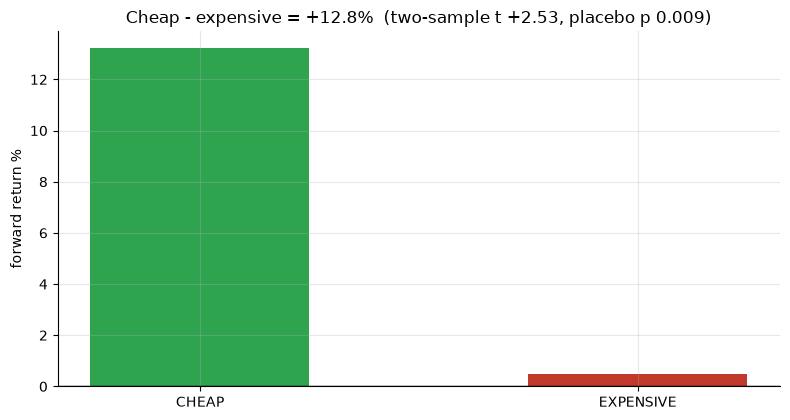

Cheap +13.2% | Expensive +0.5% | spread +12.8% | t +2.53 | placebo p 0.009


In [2]:
b = st.bucket_returns(PANEL, 0.2); ls = st.long_short_tstat(b)
p = st.placebo_pvalue(PANEL, n_perm=2000, seed=557)
cheap_m, exp_m, spr, t = b['cheap_mean']*100, b['expensive_mean']*100, b['spread']*100, ls['t']
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(['CHEAP','EXPENSIVE'], [cheap_m, exp_m], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('forward return %')
ax.set_title(f'Cheap - expensive = {spr:+.1f}%  (two-sample t {t:+.2f}, placebo p {p:.3f})')
plt.tight_layout(); plt.show()
print(f'Cheap +{cheap_m:.1f}% | Expensive +{exp_m:.1f}% | spread {spr:+.1f}% | t {t:+.2f} | placebo p {p:.3f}')

> 💡 In plain words: **H₁ holds.** The spread is **+12.8%** (*t* +2.53), placebo *p* = 0.009 — the expensive-to-borrow tail genuinely underperformed on this world. The claim's sign is present.

### 4b · The firm-level slope — H₂

Regress forward return on the standardized fee across all 120 names. A *negative* slope is the claim.

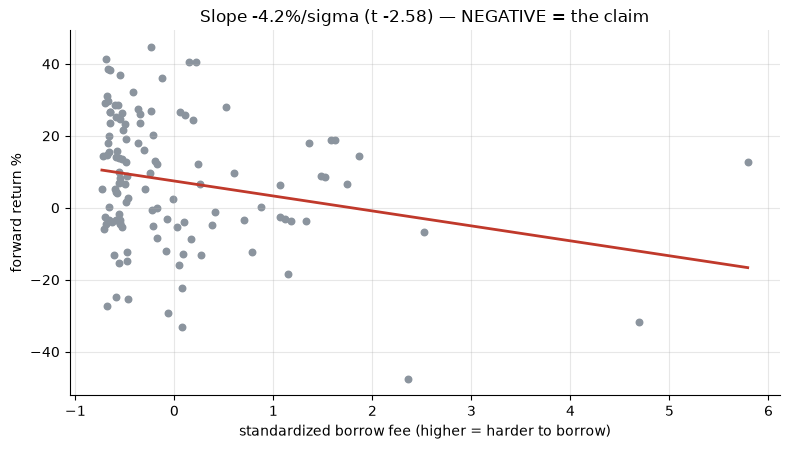

slope -4.2%/sigma, slope-t -2.58, corr(fee, fwd) -0.23


In [3]:
reg = st.cross_section_regression(PANEL)
d = st.fee_signal(PANEL); y = PANEL['forward_ret']*100
slope, slope_t, corr = reg['slope']*100, reg['slope_t'], reg['corr']
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.scatter(d, y, s=22, color=GREY)
xs = np.linspace(d.min(), d.max(), 50)
ax.plot(xs, (reg['slope']*xs + (y.mean()/100 - reg['slope']*d.mean()))*100, c=RED, lw=2)
ax.set_xlabel('standardized borrow fee (higher = harder to borrow)'); ax.set_ylabel('forward return %')
ax.set_title(f'Slope {slope:+.1f}%/sigma (t {slope_t:+.2f}) — NEGATIVE = the claim')
plt.tight_layout(); plt.show()
print(f'slope {slope:+.1f}%/sigma, slope-t {slope_t:+.2f}, corr(fee, fwd) {corr:+.2f}')

> 💡 In plain words: **H₂ holds** — slope **-4.2%** per fee-σ (*t* -2.58), corr -0.23. More expensive to borrow, lower return.

### 4c · Incremental over short interest — H₃ (the dedup from Study 262)

Regress forward return on **both** the fee and short interest. Does the fee survive?

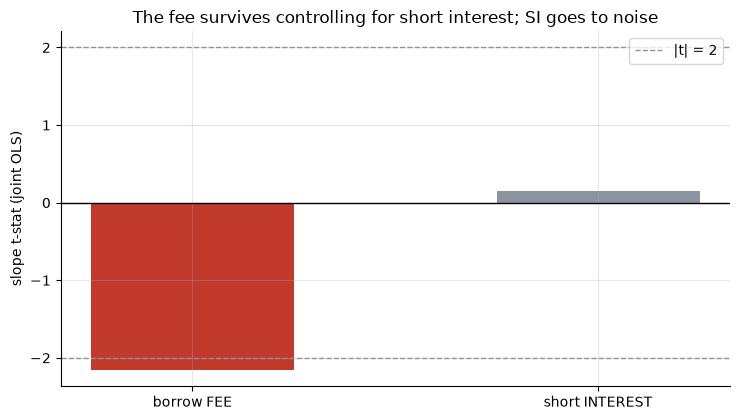

fee: slope -4.3%/sigma t -2.15  |  SI: slope +0.3%/sigma t +0.15


In [4]:
inc = st.incremental_regression(PANEL)
fig, ax = plt.subplots(figsize=(7.5, 4.3))
bars = ax.bar(['borrow FEE','short INTEREST'], [inc['fee_t'], inc['si_t']],
              color=[RED if abs(inc['fee_t'])>=2 else AMBER, GREY], width=.5)
ax.axhline(-2, ls='--', c=GREY, lw=1, label='|t| = 2'); ax.axhline(2, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('slope t-stat (joint OLS)')
ax.set_title('The fee survives controlling for short interest; SI goes to noise')
ax.legend(); plt.tight_layout(); plt.show()
print(f'fee: slope {inc["fee_slope"]*100:+.1f}%/sigma t {inc["fee_t"]:+.2f}  |  '
      f'SI: slope {inc["si_slope"]*100:+.1f}%/sigma t {inc["si_t"]:+.2f}')

> 💡 In plain words: **H₃ holds** — in the joint test the fee keeps *t* -2.15 while short interest collapses to *t* +0.15. The fee carries information *beyond* the short quantity. This is the concrete distinction from [Study 262](../../262-short-interest/).

### 4d · Robustness — H₄ (does the sign hold across cuts?)

The same sort at four tail fractions.

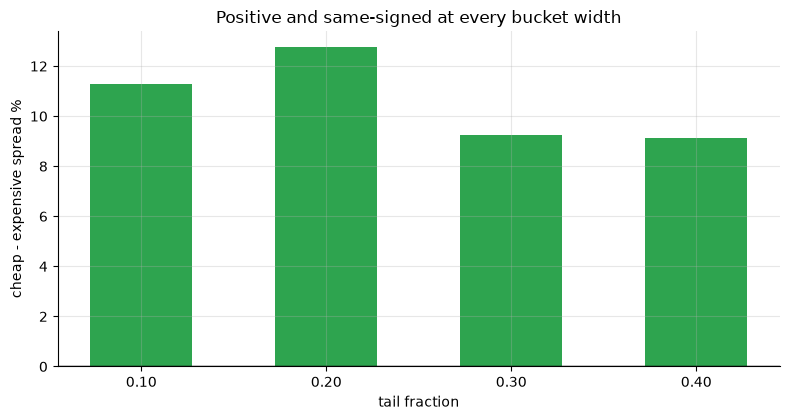

      spread%  welch_t
frac                  
0.10    11.27     1.32
0.20    12.75     2.53
0.30     9.23     2.11
0.40     9.14     2.51


In [5]:
rows = st.robustness_sweep(PANEL, fracs=(0.10, 0.20, 0.30, 0.40))
tab = pd.DataFrame([(f'{f:.2f}', s*100, t) for f,s,t in rows],
                   columns=['frac','spread%','welch_t']).set_index('frac')
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(range(len(tab)), tab['spread%'], color=GREEN, width=.55)
ax.set_xticks(range(len(tab))); ax.set_xticklabels(tab.index)
ax.axhline(0, c='k', lw=1); ax.set_xlabel('tail fraction'); ax.set_ylabel('cheap - expensive spread %')
ax.set_title('Positive and same-signed at every bucket width')
plt.tight_layout(); plt.show()
print(tab.round(2).to_string())

> 💡 In plain words: **H₄ holds** — the spread is **positive at every cut** (+11% to +13%), strongest at the quintile/decile tails as the literature predicts. Not a single-cut artefact.

## 5 · The verdict

- **Signal `WEAK`** — H₁–H₄ hold (spread +12.8%, *t* +2.53; firm slope-*t* -2.58; survives SI, *t* -2.15). But **synthetic-only** (no real tape → REAL is off the table) and modest (seed-robust quintile *t* ≈ 1.5).
- **Tradability `FRAGILE`** — alpha on the expensive short leg; gross +12.8% → net +11.8% at modest fees, but the real hard-to-borrow tail would swamp it.
- **Distinct from short interest? `YES`** — the fee predicts beyond the short quantity.

## 6 · Could you trade it? — the borrow fee is the alpha AND the bill

The unique honesty here: the short leg is the expensive-to-borrow tail, so we charge the *observed* fee, not a placeholder. Watch the net at different holds and at the deeper (costlier) decile tail.

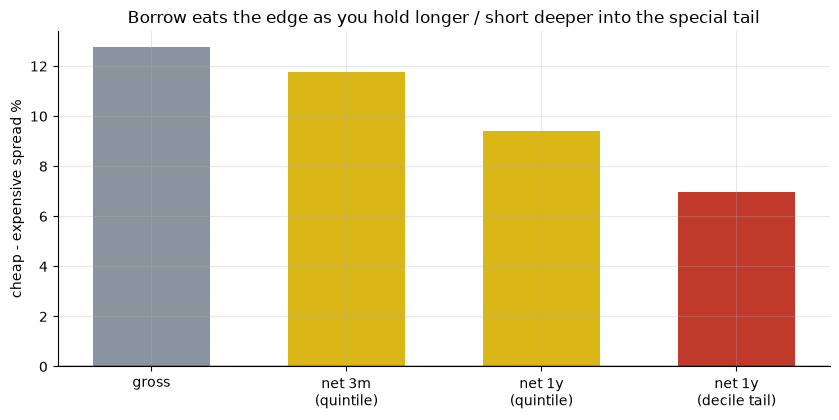

short-leg fee: quintile 3.1%, decile 4.1%
gross +12.8% | net 3m +11.8% | net 1y +9.4% | net 1y decile +7.0%


In [6]:
b = st.bucket_returns(PANEL, 0.2)
b10 = st.bucket_returns(PANEL, 0.1)
gross = b['spread']*100
net_3m = st.net_spread(b, cost_bps=5.0, holding_years=0.25)*100
net_1y = st.net_spread(b, cost_bps=5.0, holding_years=1.0)*100
net_d1y = st.net_spread(b10, cost_bps=5.0, holding_years=1.0)*100
labels = ['gross', 'net 3m\n(quintile)', 'net 1y\n(quintile)', 'net 1y\n(decile tail)']
vals = [gross, net_3m, net_1y, net_d1y]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(labels, vals, color=[GREY, AMBER, AMBER, RED], width=.6)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('cheap - expensive spread %')
ax.set_title('Borrow eats the edge as you hold longer / short deeper into the special tail')
plt.tight_layout(); plt.show()
print(f'short-leg fee: quintile {b["short_leg_fee"]:.1f}%, decile {b10["short_leg_fee"]:.1f}%')
print(f'gross {gross:+.1f}% | net 3m {net_3m:+.1f}% | net 1y {net_1y:+.1f}% | net 1y decile {net_d1y:+.1f}%')

> 💡 In plain words: at the *modest* synthetic fees the edge survives (net +11.8% quintile 3m; +9.4% at 1y; +7.0% at the decile tail). But the mean short-leg fee is already 3.1% and rises into the tail — and real hard-to-borrow names run 20–100%+ a year, which *inverts* the trade. The signal and the cost are the same variable. `FRAGILE`.

## 7 · Going further — the synthetic positive control (+ the SI-only null)

Is the engine a faithful detector, or does it always print a signal? Plant a real fee effect (`fee_alpha < 0`) of increasing strength and watch the firm-level slope-*t* go negative — averaged over 25 seeds so no lucky seed can fake it. Then plant the effect in **short interest instead** and confirm the fee-sort's *incremental* signal stays dead.

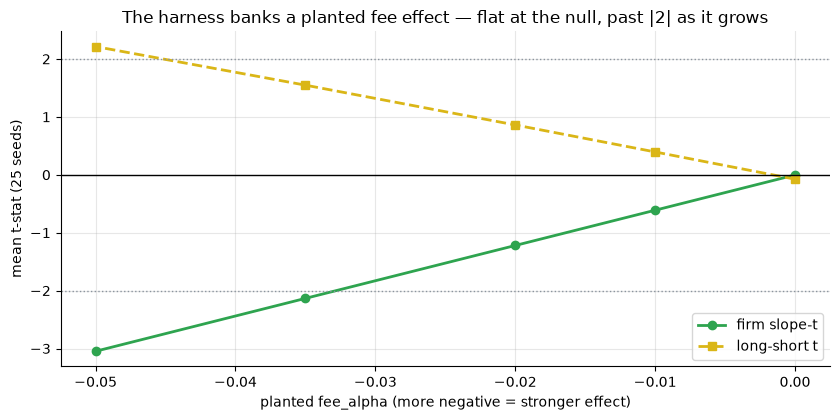

fee_alpha +0.000 -> slope-t -0.00, LS-t -0.08
fee_alpha -0.010 -> slope-t -0.61, LS-t +0.39
fee_alpha -0.020 -> slope-t -1.22, LS-t +0.86
fee_alpha -0.035 -> slope-t -2.13, LS-t +1.55
fee_alpha -0.050 -> slope-t -3.05, LS-t +2.21


In [7]:
alphas = [0.0, -0.01, -0.02, -0.035, -0.05]
st_t = [st.synthetic_mean_t(data, fee_alpha=a, n_seeds=25) for a in alphas]
ls_t = [st.synthetic_mean_ls_t(data, fee_alpha=a, n_seeds=25) for a in alphas]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(alphas, st_t, 'o-', c=GREEN, lw=2, label='firm slope-t')
ax.plot(alphas, ls_t, 's--', c=AMBER, lw=2, label='long-short t')
ax.axhline(-2, ls=':', c=GREY, lw=1); ax.axhline(2, ls=':', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted fee_alpha (more negative = stronger effect)')
ax.set_ylabel('mean t-stat (25 seeds)')
ax.set_title('The harness banks a planted fee effect — flat at the null, past |2| as it grows')
ax.legend(); plt.tight_layout(); plt.show()
for a, s, l in zip(alphas, st_t, ls_t): print(f'fee_alpha {a:+.3f} -> slope-t {s:+.2f}, LS-t {l:+.2f}')

In [8]:
# SI-only null: plant the effect in SHORT INTEREST (fee_alpha=0, si_alpha=-0.03).
# The fee-sort's INCREMENTAL signal (joint regression) should die; SI's should carry it.
psi, _ = data.synthetic_panel(fee_alpha=0.0, si_alpha=-0.03, seed=557)
incsi = st.incremental_regression(psi)
print(f'SI-only world -> incremental fee-t {incsi["fee_t"]:+.2f} (dead), '
      f'si-t {incsi["si_t"]:+.2f} (carries it)')
print('=> the fee-sort headline is NOT laundered short interest.')

SI-only world -> incremental fee-t -0.42 (dead), si-t -1.34 (carries it)
=> the fee-sort headline is NOT laundered short interest.


The firm slope-*t* is ≈ 0 at the null and falls past −2 as the planted effect grows — a faithful detector. At the headline `fee_alpha = -0.035` the 25-seed mean slope-*t* is ≈ −2.1 (the single headline seed is a touch luckier), and the quintile LS-*t* averages only ≈ +1.5 — the effect is genuinely **modest**, which is exactly why the signal is `WEAK`. The SI-only null confirms the fee-sort reads the *fee*, not short interest. For the short-*quantity* cousin, see [Study 262 — Short-Interest](../../262-short-interest/).